Dataset cleanup

In [1]:
import pandas as pd
import os

# Keep only columns from RNG_SEED onward
def trim(path):
    df = pd.read_csv(path)
    return df.loc[:, df.columns[df.columns.get_loc('RNG_SEED'):]]

a = trim('original_csv_files/full_sweep.csv')
b = trim('original_csv_files/random_sweep.csv')

# Ensure the remaining column headers match
assert list(a.columns) == list(b.columns), 'Column headers do not match!'

# Combine and shuffle rows
full = pd.concat([a, b], ignore_index=True)
full = full.sample(frac=1, random_state=42).reset_index(drop=True)

# Drop columns we don't model on:
#   RNG_SEED         - simulation random seed, a pure noise input
#   citric_total_mmol - ~zero variance (all values ~0), nothing to predict
full = full.drop(columns=['RNG_SEED', 'citric_total_mmol'])

# Drop any rows that have blank cells
full = full.dropna().reset_index(drop=True)

# Save combined set
os.makedirs('model_csv_files', exist_ok=True)
full.to_csv('model_csv_files/full_set.csv', index=False)

# 80/20 split into training and validation sets
n_train = int(len(full) * 0.8)
full.iloc[:n_train].to_csv('model_csv_files/training_set.csv', index=False)
full.iloc[n_train:].to_csv('model_csv_files/validation_set.csv', index=False)

print(f'Columns: {len(full.columns)} | Total: {len(full)} | Train: {n_train} | Val: {len(full) - n_train}')

Columns: 17 | Total: 2812 | Train: 2249 | Val: 563


Surrogate model training and validation

Gradient boost

In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train_set = pd.read_csv("model_csv_files/training_set.csv")
valid_set = pd.read_csv("model_csv_files/validation_set.csv")

feature_cols = ['MU_MAX','DEPLETION_RADIUS','HYPHA_RADIUS_UM','PSI_BRANCH','MIN_BRANCH_ANGLE_DEG','APICAL_BRANCH_MIN_STEP','LATERAL_DISTANCE_FROM_TIP','PHI_N','PHI_P','LATERAL_BRANCH_MIN_STEP','MAX_DEVIATION_DEG','nutrient_pm_fraction']
target_cols = ['avg_length_um','avg_volume_um3','total_tips','n_apical_events','n_lateral_events']

train_x = train_set[feature_cols]
valid_x = valid_set[feature_cols]

# Gradient boosting on a log1p-transformed target (tames the 6-9 skew).
# Trees need no feature scaling, so no StandardScaler here.
results = []
for target in target_cols:
    y_train = train_set[target]
    y_valid = valid_set[target]

    model = TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            max_iter=800, learning_rate=0.3, max_leaf_nodes=31, random_state=47,
        ),
        func=np.log1p, inverse_func=np.expm1,
    )
    model.fit(train_x, y_train)
    train_pred = model.predict(train_x)
    pred = model.predict(valid_x)

    results.append({
        'target': target,
        'train_r2': r2_score(y_train, train_pred),
        'valid_r2': r2_score(y_valid, pred),
        'train_r2_log': r2_score(np.log1p(y_train), np.log1p(np.clip(train_pred, 0, None))),
        'valid_r2_log': r2_score(np.log1p(y_valid), np.log1p(np.clip(pred, 0, None))),
        'MAE': mean_absolute_error(y_valid, pred),
        'RMSE': np.sqrt(mean_squared_error(y_valid, pred)),
    })

results_df = pd.DataFrame(results).set_index('target')
print(results_df.round(4).to_string())


                  train_r2  valid_r2  train_r2_log  valid_r2_log       MAE       RMSE
target                                                                               
avg_length_um       0.9999    0.8274        0.9985        0.9517   88.9509   329.1351
avg_volume_um3      1.0000    0.9181        0.9992        0.9491  713.5942  2581.0408
total_tips          0.9999    0.8726        0.9860        0.9183   22.3037    76.2567
n_apical_events     0.9997    0.7995        0.9687        0.8736   12.2425    44.5785
n_lateral_events    1.0000    0.8507        1.0000        0.9666   13.6732    51.6227


## Part 3 — Calibration by MCMC (gradient-boost surrogate)

Use the gradient-boost surrogate as a fast forward model (`parameters -> outputs`) inside an
MCMC search that answers the *inverse* question: which parameter values are consistent with a
set of observed outputs? The result is a posterior distribution per parameter (corner plot),
showing which parameters the data pins down and which are degenerate.

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor

# Train the forward surrogate on ALL data (Parts 1 & 2 already folded in).
# Same tuned hyperparameters as the gradient-boost cell above.
full = pd.read_csv("model_csv_files/full_set.csv")

feature_cols = ['MU_MAX','DEPLETION_RADIUS','HYPHA_RADIUS_UM','PSI_BRANCH','MIN_BRANCH_ANGLE_DEG','APICAL_BRANCH_MIN_STEP','LATERAL_DISTANCE_FROM_TIP','PHI_N','PHI_P','LATERAL_BRANCH_MIN_STEP','MAX_DEVIATION_DEG','nutrient_pm_fraction']
target_cols = ['avg_length_um','avg_volume_um3','total_tips','n_apical_events','n_lateral_events']

X_all = full[feature_cols].to_numpy()

# One gradient-boost surrogate per output. Fit on numpy arrays so the fast
# per-step MCMC predictions don't trip sklearn's feature-name checks.
surrogates = {}
for t in target_cols:
    m = TransformedTargetRegressor(
        regressor=HistGradientBoostingRegressor(
            max_iter=800, learning_rate=0.10, max_leaf_nodes=31, random_state=47,
        ),
        func=np.log1p, inverse_func=np.expm1,
    )
    m.fit(X_all, full[t].to_numpy())
    surrogates[t] = m

# =====================================================================
#  Which parameters MCMC actually explores. The rest are held fixed at
#  the values below (edit as needed) and passed through to the surrogate
#  unchanged on every step.
# =====================================================================
mcmc_feature_cols = ['PSI_BRANCH', 'DEPLETION_RADIUS', 'HYPHA_RADIUS_UM', 'MU_MAX', 'MAX_DEVIATION_DEG']

FIXED_PARAMS = {
    'MIN_BRANCH_ANGLE_DEG':      50.0,
    'APICAL_BRANCH_MIN_STEP':    3.0,
    'LATERAL_DISTANCE_FROM_TIP': 4.6,
    'PHI_N':                     0.15,
    'PHI_P':                     0.15,
    'LATERAL_BRANCH_MIN_STEP':   7.0,
    'nutrient_pm_fraction':      0.05,
}
assert set(FIXED_PARAMS) | set(mcmc_feature_cols) == set(feature_cols), \
    'mcmc_feature_cols + FIXED_PARAMS must cover exactly feature_cols'
# =====================================================================

mcmc_idx  = [feature_cols.index(c) for c in mcmc_feature_cols]
fixed_idx = [feature_cols.index(c) for c in FIXED_PARAMS]
fixed_vec = np.array([FIXED_PARAMS[c] for c in FIXED_PARAMS])

def surrogate_predict(theta):
    """theta: (n, len(mcmc_feature_cols)) sampled params -> (n, n_outputs) predicted outputs.
    Parameters in FIXED_PARAMS are filled in before calling the surrogate."""
    theta = np.atleast_2d(theta)
    full_theta = np.empty((theta.shape[0], len(feature_cols)))
    full_theta[:, mcmc_idx] = theta
    full_theta[:, fixed_idx] = fixed_vec
    return np.column_stack([surrogates[t].predict(full_theta) for t in target_cols])

# Uniform-prior support = the parameter ranges actually covered by the sweeps
# (only for the params MCMC samples).
param_lo = full[mcmc_feature_cols].min().to_numpy()
param_hi = full[mcmc_feature_cols].max().to_numpy()

print(f'Surrogate trained on {len(full)} runs | {len(feature_cols)} params -> {len(target_cols)} outputs')
print(f'MCMC samples {len(mcmc_feature_cols)} params; {len(FIXED_PARAMS)} held fixed')
print(pd.DataFrame({'param': mcmc_feature_cols, 'prior_low': param_lo, 'prior_high': param_hi}).round(4).to_string(index=False))
print(pd.DataFrame({'param': list(FIXED_PARAMS), 'fixed_value': list(FIXED_PARAMS.values())}).round(4).to_string(index=False))


Surrogate trained on 2812 runs | 12 params -> 5 outputs
MCMC samples 5 params; 7 held fixed
            param  prior_low  prior_high
       PSI_BRANCH     0.0009      1.9887
 DEPLETION_RADIUS     0.0058      9.9946
  HYPHA_RADIUS_UM     0.0007      2.7989
           MU_MAX     0.0063     19.1449
MAX_DEVIATION_DEG     0.0032    139.9896
                    param  fixed_value
     MIN_BRANCH_ANGLE_DEG        50.00
   APICAL_BRANCH_MIN_STEP         3.00
LATERAL_DISTANCE_FROM_TIP         4.60
                    PHI_N         0.15
                    PHI_P         0.15
  LATERAL_BRANCH_MIN_STEP         7.00
     nutrient_pm_fraction         0.05


In [4]:
import numpy as np
import emcee

# =====================================================================
#  INPUTS — fill these with the real experimental measurements.
#  (Pre-filled with the hand-tuned baseline outputs as a placeholder,
#   from sensitivity_analysis/baseline.csv. Calibrating to these is a
#   self-consistency check: the MCMC should recover the tuned params.)
# =====================================================================
OBSERVED = {
    'avg_length_um':    85.96,
    'avg_volume_um3':   529.28,
    'total_tips':       10.0,
    'n_apical_events':  6.0,
    'n_lateral_events': 0.0,
}
# 1-sigma uncertainty per output = the RNG-seed noise floor (Part 1,
# from sensitivity_analysis/seed_summary.csv). Widen any value to trust
# that measurement less. A floor keeps every sigma strictly positive.
SIGMA = {
    'avg_length_um':    12.39,
    'avg_volume_um3':   76.28,
    'total_tips':       3.48,
    'n_apical_events':  3.33,
    'n_lateral_events': 1.00,   # seed std was 0 -> use a small floor
}
# =====================================================================

y_obs = np.array([OBSERVED[t] for t in target_cols])
y_sig = np.array([SIGMA[t]    for t in target_cols])
assert (y_sig > 0).all(), 'Every SIGMA must be > 0'

def log_prior(theta):
    inside = np.all((theta >= param_lo) & (theta <= param_hi), axis=-1)
    return np.where(inside, 0.0, -np.inf)

def log_likelihood(theta):
    # Gaussian match score: close to observed (within noise) -> high score.
    resid = (surrogate_predict(theta) - y_obs) / y_sig
    return -0.5 * np.sum(resid ** 2, axis=1)

def log_prob(theta):
    theta = np.atleast_2d(theta)
    lp = log_prior(theta)
    ll = np.where(np.isfinite(lp), log_likelihood(theta), 0.0)
    return lp + ll

ndim = len(mcmc_feature_cols)
nwalkers = 40
rng = np.random.default_rng(42)
p0 = param_lo + rng.random((nwalkers, ndim)) * (param_hi - param_lo)   # start across the prior box

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_prob, vectorize=True,
    # DE moves mix far better than the default stretch move in this space.
    moves=[(emcee.moves.DEMove(), 0.8), (emcee.moves.DESnookerMove(), 0.2)],
)

# NOTE: ~6500 steps x 40 walkers x 5 surrogates takes roughly 10-15 min.
state = sampler.run_mcmc(p0, 1500, progress=True)   # burn-in: let walkers find the good region
sampler.reset()                                     # discard burn-in
sampler.run_mcmc(state, 5000, progress=True)        # production

# --- convergence diagnostics ---
print('\nMean acceptance fraction:', round(float(np.mean(sampler.acceptance_fraction)), 3),
      '(healthy ~0.2-0.5)')
try:
    tau = sampler.get_autocorr_time(tol=0)
    n_eff = int(sampler.get_chain(flat=True).shape[0] / np.mean(tau))
    print('Max autocorr time:', round(float(np.max(tau)), 1),
          '| approx effective samples:', n_eff)
except Exception as e:
    print('Autocorr estimate:', e)


100%|██████████| 5000/5000 [31:30<00:00,  2.64it/s]  


Mean acceptance fraction: 0.066 (healthy ~0.2-0.5)
Max autocorr time: 161.0 | approx effective samples: 1483


            param  median  ci_2.5%  ci_97.5%  prior_low  prior_high  constrained_%
       PSI_BRANCH  1.2374   0.0650    1.9455     0.0009      1.9887         5.3965
 DEPLETION_RADIUS  6.0398   1.1245    9.7854     0.0058      9.9946        13.2944
  HYPHA_RADIUS_UM  1.4400   1.0972    1.9224     0.0007      2.7989        70.5094
           MU_MAX 11.9011   5.7805   18.6159     0.0063     19.1449        32.9344
MAX_DEVIATION_DEG 33.2007  18.4229  129.3247     0.0032    139.9896        20.7768


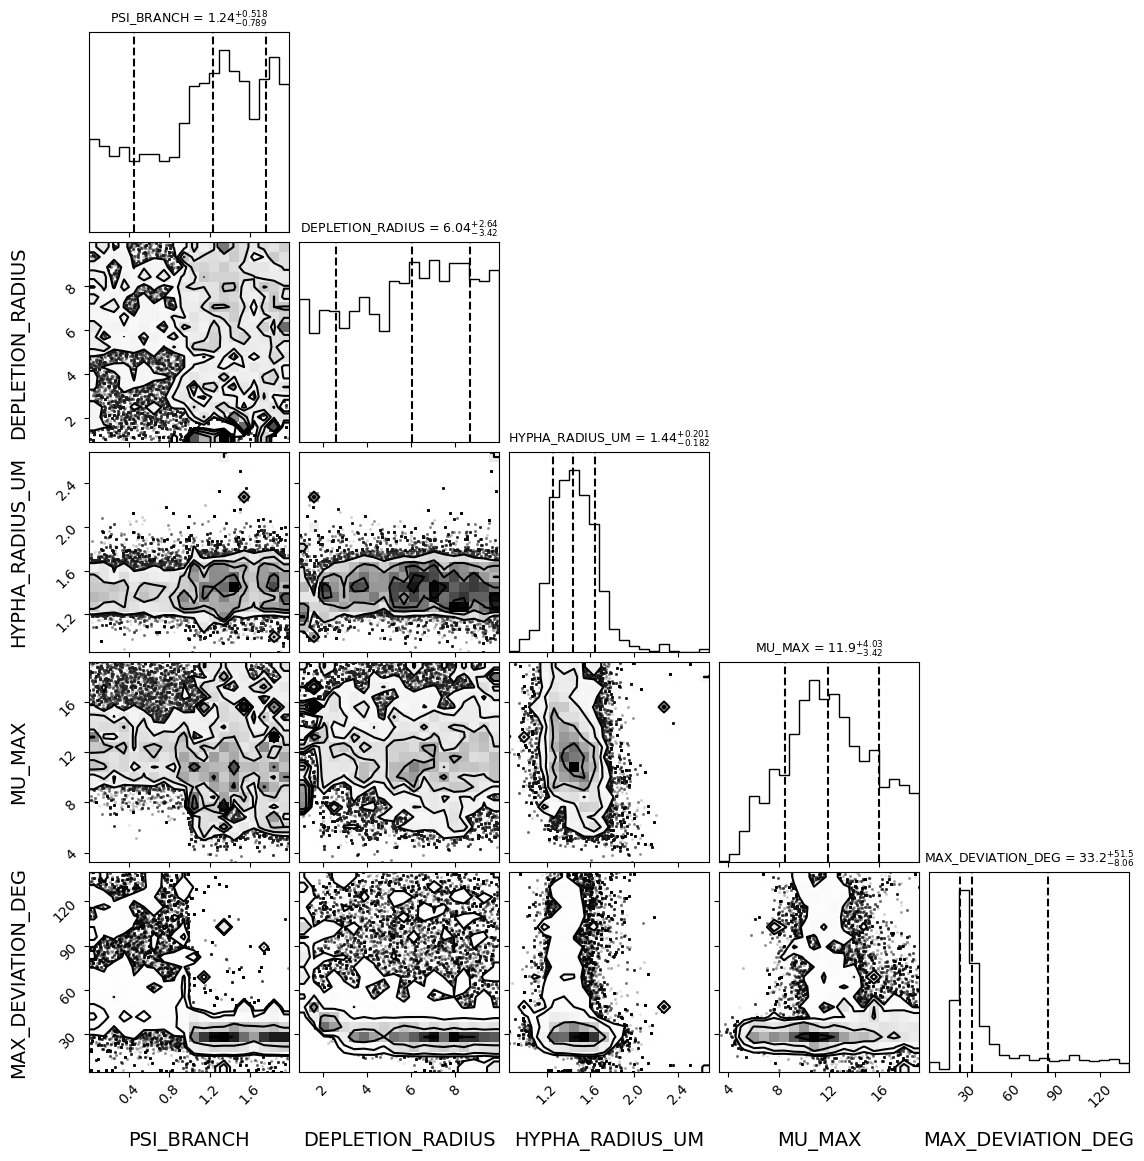

In [13]:
import corner
import numpy as np
import pandas as pd
import os

flat = sampler.get_chain(flat=True)   # (n_samples, n_params) posterior

# Corner plot: diagonals = each parameter's posterior (sharp peak = well
# determined; flat = unconstrained); off-diagonals = pairwise degeneracies.
fig = corner.corner(
    flat, labels=mcmc_feature_cols, show_titles=True, title_fmt='.3g',
    quantiles=[0.16, 0.5, 0.84], title_kwargs={'fontsize': 9}, label_kwargs={'fontsize': 14},
)
os.makedirs('exports_and_results', exist_ok=True)
fig.savefig('exports_and_results/mcmc_corner.png', dpi=150, bbox_inches='tight')

# Posterior summary: median and 95% credible interval per parameter.
q = np.percentile(flat, [2.5, 50, 97.5], axis=0)
summary = pd.DataFrame({
    'param': mcmc_feature_cols,
    'median': q[1], 'ci_2.5%': q[0], 'ci_97.5%': q[2],
    'prior_low': param_lo, 'prior_high': param_hi,
})
# "constrained %": how much narrower the 95% CI is than the prior (100% = pinned, 0% = flat)
summary['constrained_%'] = 100 * (1 - (q[2] - q[0]) / (param_hi - param_lo))
summary.to_csv('exports_and_results/mcmc_posterior_summary.csv', index=False)
print(summary.round(4).to_string(index=False))


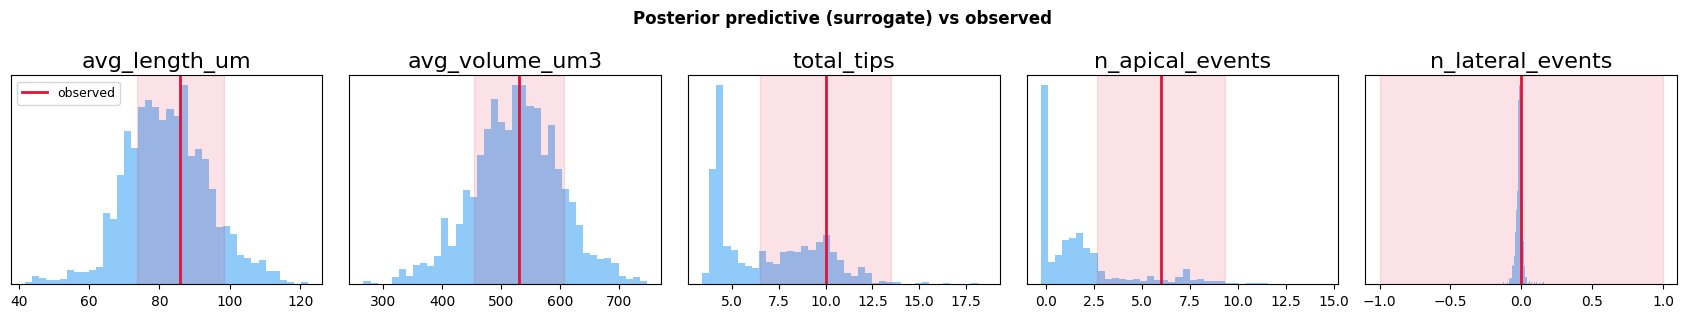

          target  observed  post_median  z_score
   avg_length_um     85.96       81.926   -0.326
  avg_volume_um3    529.28      527.519   -0.023
      total_tips     10.00        6.464   -1.016
 n_apical_events      6.00        1.130   -1.462
n_lateral_events      0.00       -0.010   -0.010


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Validation / posterior predictive: push a sample of posterior parameter sets
# back through the surrogate and check the predicted output distribution brackets
# the observed value. (For a final check, re-run these same parameter sets through
# the REAL simulator instead of the surrogate.)
n_draw = min(2000, flat.shape[0])
idx = rng.choice(flat.shape[0], size=n_draw, replace=False)
post_pred = surrogate_predict(flat[idx])   # (n_draw, n_outputs)

fig, axes = plt.subplots(1, len(target_cols), figsize=(3.4 * len(target_cols), 3.2))
for j, t in enumerate(target_cols):
    ax = axes[j]
    ax.hist(post_pred[:, j], bins=40, color='#90caf9', edgecolor='none')
    ax.axvline(y_obs[j], color='crimson', lw=2, label='observed')
    ax.axvspan(y_obs[j] - y_sig[j], y_obs[j] + y_sig[j], color='crimson', alpha=0.12)
    ax.set_title(t, fontsize=16)
    ax.set_yticks([])
axes[0].legend(fontsize=9)
fig.suptitle('Posterior predictive (surrogate) vs observed', fontweight='bold')
fig.tight_layout()
fig.savefig('exports_and_results/mcmc_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# How well does the posterior reproduce each observed output?
med = np.median(post_pred, axis=0)
check = pd.DataFrame({
    'target': target_cols, 'observed': y_obs, 'post_median': med,
    'z_score': (med - y_obs) / y_sig,   # |z| < ~1 means consistent within the noise floor
})
print(check.round(3).to_string(index=False))
